<a href="https://colab.research.google.com/github/junaidkhan37/EVResalePricePrediction/blob/main/EVPricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Business Understanding

EV Resale Price Prediction

Objective

Predict the resale price of electric vehicles (EVs) based on historical data and vehicle attributes.

From a business standpoint, this solves a pricing inefficiency problem in the secondary EV market.

Dataset

This is a raw dataset of used cars from the year 2000 to 2023


Who benefits

Dealerships → Optimize trade-in and resale pricing

Online marketplaces → Improve price recommendations

Consumers → Fair valuation for buying/selling

Fleet owners / Leasing companies → Residual value forecasting

Target: Price

Business Success Criteria

Reduce pricing error in resale listings
Enable data-driven pricing decisions
Improve profit margins (buy low, sell accurately)
Increase user trust in price recommendations

Data Science Success Criteria

Define measurable metrics:
RMSE (Root Mean Squared Error) → primary metric
MAE (Mean Absolute Error) → interpretability in dollars
R² score → variance explained

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.model_selection import GridSearchCV
import shap

import warnings
warnings.filterwarnings('ignore')


Data Understanding

In [2]:
##Load the Dataset
df = pd.read_csv("car_price_prediction_.csv")
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [3]:
df.shape
df.columns
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   object 
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   object 
 5   Transmission  2500 non-null   object 
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   object 
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 195.4+ KB


,0
Car ID,0
Brand,0
Year,0
Engine Size,0
Fuel Type,0
Transmission,0
Mileage,0
Condition,0
Price,0
Model,0


In [12]:
##Missing Data

# Common values that also represent missing data
other_missing_values = ["?", "—", "N/A", "null", ""]

In [13]:
def missing_data_stats(df) -> pd.DataFrame:

    other_missing_values = ["?", "—", "N/A", "null", ""]

    stats = {}

    for col in df.columns:
        counts = df[col].isin(other_missing_values).sum()
        missing_nan = df[col].isna().sum()
        stats[col] = {
            "total_rows": len(df),
            'missing_nan': missing_nan,
            'missing_other': counts,
            "true_missing": counts + missing_nan,
            "true_missing_pct":  ((counts + missing_nan) / len(df) * 100).round(1),
            "unique": df[col].nunique()
        }
    return pd.DataFrame(stats).T

missing_data_stats(df)

,total_rows,missing_nan,missing_other,true_missing,true_missing_pct,unique
Brand,2500.0,0.0,0.0,0.0,0.0,7.0
Year,2500.0,0.0,0.0,0.0,0.0,24.0
Engine Size,2500.0,0.0,0.0,0.0,0.0,51.0
Fuel Type,2500.0,0.0,0.0,0.0,0.0,4.0
Transmission,2500.0,0.0,0.0,0.0,0.0,2.0
Mileage,2500.0,0.0,0.0,0.0,0.0,2490.0
Condition,2500.0,0.0,0.0,0.0,0.0,3.0
Price,2500.0,0.0,0.0,0.0,0.0,2499.0
Model,2500.0,0.0,0.0,0.0,0.0,28.0


In [21]:
df_before_eda = df.copy()

Detecting Outliers

Similar to missing data, outliers need to be identified and reviewed in order to determine how to best handle them in your specific project. This is because outliers can create 'noise' in your model during both EDA and model training. For example, in EDA an outlier value can positively or negatively skew your statistical analysis, impacting your mean value and intepretation of its distribution.

One way to detect outliers in numerical data is by using statistical methods such as Z-score

In [22]:
numerical_cols = df.select_dtypes(include="int").columns.tolist()

In [23]:
# --- Z-score based detection ---
z_thresh = 3
z_scores = (df[numerical_cols] - df[numerical_cols].mean()) / df[numerical_cols].std(ddof=0)
outliers = (z_scores.abs() > z_thresh).any(axis=1)

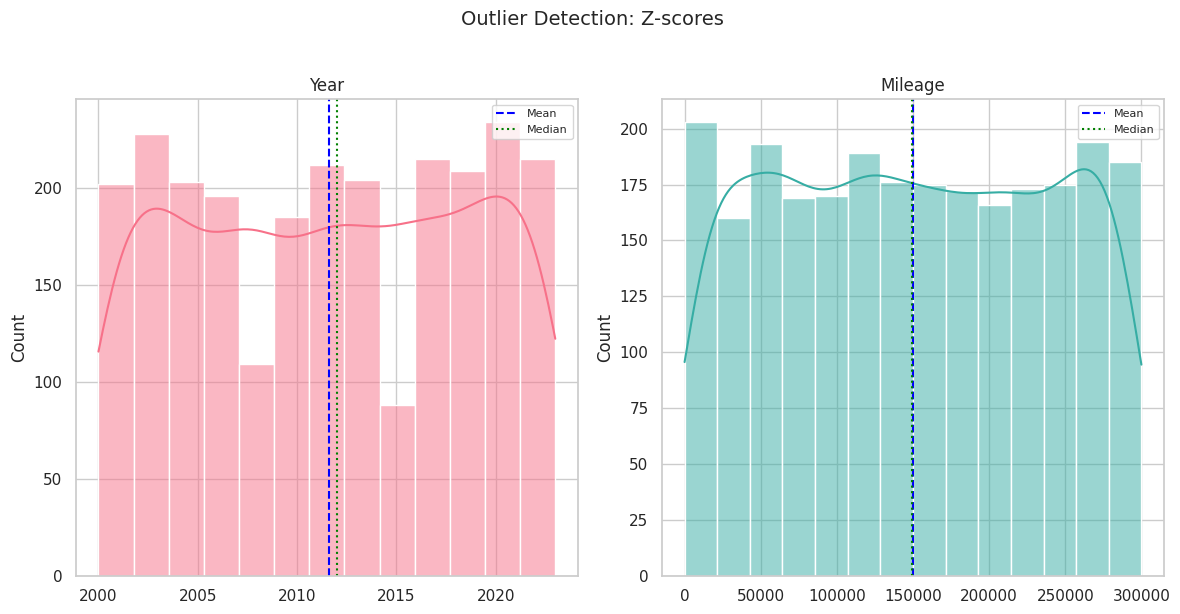

In [24]:
FIGSIZE = (12, 6)
LABEL_FONTSIZE = 12
TITLE_FONTSIZE = 14

n_cols = len(numerical_cols)
colors = sns.color_palette("husl", n_cols)

fig, axes = plt.subplots(1, n_cols, figsize=FIGSIZE)
axes = [axes] if n_cols == 1 else axes

for idx, col in enumerate(numerical_cols):
    ax = axes[idx]
    s = df[col].dropna()

    # Base histogram
    sns.histplot(s, kde=True, ax=ax, color=colors[idx])

    # Identify column-specific outliers
    col_outliers = z_scores[col].abs() > z_thresh
    x_out = df.loc[col_outliers, col].dropna()

    # Overlay outlier lines
    for val in x_out:
        ax.axvline(val, color="red", linewidth=2, label="Outlier")

    # Mean & median
    mean_val = s.mean()
    median_val = s.median()

    ax.axvline(mean_val, color='blue', linestyle='--', linewidth=1.5,label=f'Mean')
    ax.axvline(median_val, color='green', linestyle=':',linewidth=1.5, label=f'Median')

    ax.set_title(col, fontsize=LABEL_FONTSIZE)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

plt.suptitle("Outlier Detection: Z-scores",fontsize=TITLE_FONTSIZE, y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# Detect outlier rows
outlier_rows = df.loc[outliers]
#Drop outlier rows
df = df.loc[~outliers].copy()

In [ ]:
##Now we can see the before and after of our EDA

Before EDA

In [25]:
df_before_eda

,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang
...,...,...,...,...,...,...,...,...,...
2495,Audi,2020,2.4,Petrol,Automatic,22650,Like New,61384.10,Q5
2496,Audi,2001,5.7,Hybrid,Manual,77701,Like New,24710.35,A3
2497,Ford,2021,1.1,Hybrid,Manual,272827,Like New,29902.45,Fiesta
2498,Audi,2002,4.5,Diesel,Manual,229164,Like New,46085.67,Q5


After EDA

In [31]:
df

,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang
...,...,...,...,...,...,...,...,...,...
2495,Audi,2020,2.4,Petrol,Automatic,22650,Like New,61384.10,Q5
2496,Audi,2001,5.7,Hybrid,Manual,77701,Like New,24710.35,A3
2497,Ford,2021,1.1,Hybrid,Manual,272827,Like New,29902.45,Fiesta
2498,Audi,2002,4.5,Diesel,Manual,229164,Like New,46085.67,Q5


In [ ]:
##Column Data types

Can easily convert any column data type into a category by determining the no. of unique values threshold required to make a category.

In [33]:
threshold = 10
categorical_cols = [col for col in df.columns if df[col].nunique() < threshold]

df = convert_dtypes(df, int_list=None, dt_list=None, cat_list=categorical_cols)

Missing Data

Analyse first to understand if there is a pattern in what's missing i.e. not MCAR (missing completely at random)

In [34]:
missing_data_stats(df)

,total_rows,missing_nan,missing_other,true_missing,true_missing_pct,unique
Brand,2500.0,0.0,0.0,0.0,0.0,7.0
Year,2500.0,0.0,0.0,0.0,0.0,24.0
Engine Size,2500.0,0.0,0.0,0.0,0.0,51.0
Fuel Type,2500.0,0.0,0.0,0.0,0.0,4.0
Transmission,2500.0,0.0,0.0,0.0,0.0,2.0
Mileage,2500.0,0.0,0.0,0.0,0.0,2490.0
Condition,2500.0,0.0,0.0,0.0,0.0,3.0
Price,2500.0,0.0,0.0,0.0,0.0,2499.0
Model,2500.0,0.0,0.0,0.0,0.0,28.0


In [36]:
##Identify Target Variables

target_candidates = [col for col in df.columns if 'price' in col.lower()]
print("Target candidates:", target_candidates)

target = target_candidates[0]
print("Selected target:", target)

Target candidates: ['Price']
Selected target: Price


In [37]:
##Identify Numerical Features

numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_features = [col for col in numerical_features if col != target]

print("Numerical features:")
print(numerical_features)

Numerical features:
['Year', 'Engine Size', 'Mileage']


In [38]:
##Identify Categorical Features

categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Categorical features:")
print(categorical_features)

Categorical features:
['Brand', 'Fuel Type', 'Transmission', 'Condition', 'Model']


In [39]:
##Check specific expected columns

expected_cols = ['mileage', 'range', 'battery', 'year', 'brand', 'model', 'transmission', 'fuel']
found_cols = [col for col in df.columns if any(ec in col.lower() for ec in expected_cols)]

print("Relevant EV-related columns found:")
print(found_cols)

Relevant EV-related columns found:
['Brand', 'Year', 'Fuel Type', 'Transmission', 'Mileage', 'Model']


In [41]:
##Define Numerical Features
numerical_features = ["Year", "Engine Size", "Mileage"]

In [42]:
##Define Categorical Features
categorical_features = ["Brand", "Fuel Type", "Transmission", "Condition", "Model"]

In [43]:
print("Target:", target)
print("Numerical:", numerical_features)
print("Categorical:", categorical_features)

Target: Price
Numerical: ['Year', 'Engine Size', 'Mileage']
Categorical: ['Brand', 'Fuel Type', 'Transmission', 'Condition', 'Model']


Visualization

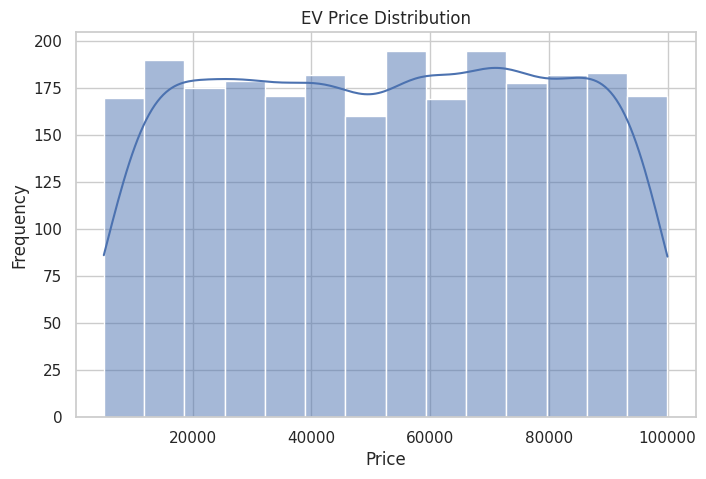

In [44]:
##Price Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["Price"], kde=True)
plt.title("EV Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

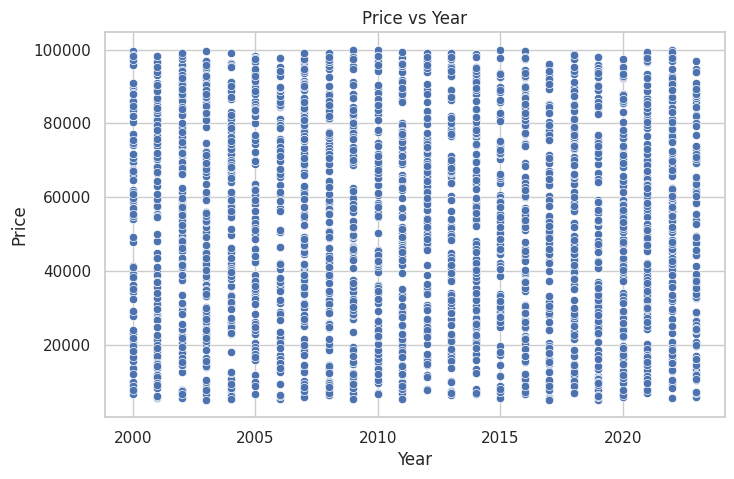

In [45]:
##Price vs Year

plt.figure(figsize=(8,5))
sns.scatterplot(x="Year", y="Price", data=df)
plt.title("Price vs Year")
plt.show()

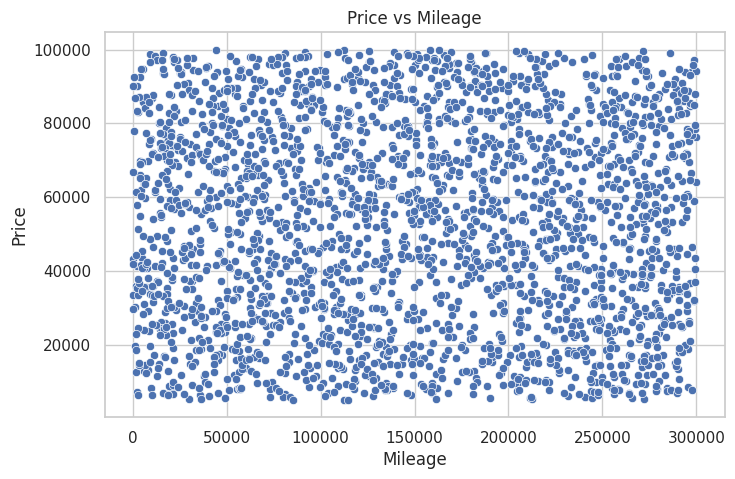

In [46]:
##Price vs Mileage

plt.figure(figsize=(8,5))
sns.scatterplot(x="Mileage", y="Price", data=df)
plt.title("Price vs Mileage")
plt.show()

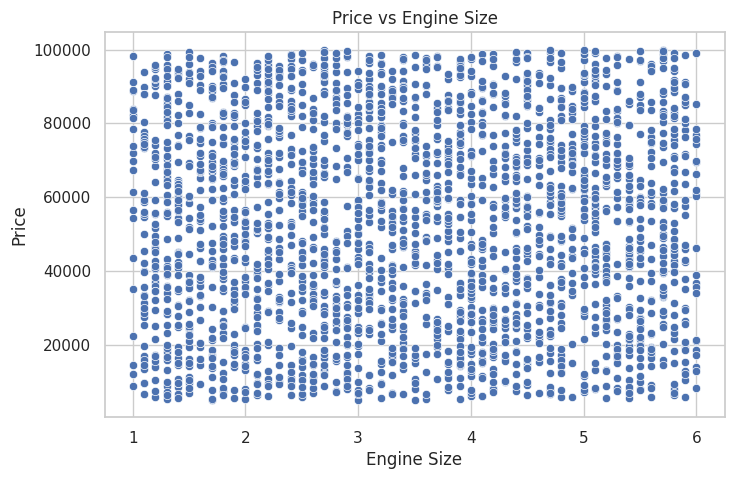

In [47]:
##Price vs Engine Size

plt.figure(figsize=(8,5))
sns.scatterplot(x="Engine Size", y="Price", data=df)
plt.title("Price vs Engine Size")
plt.show()

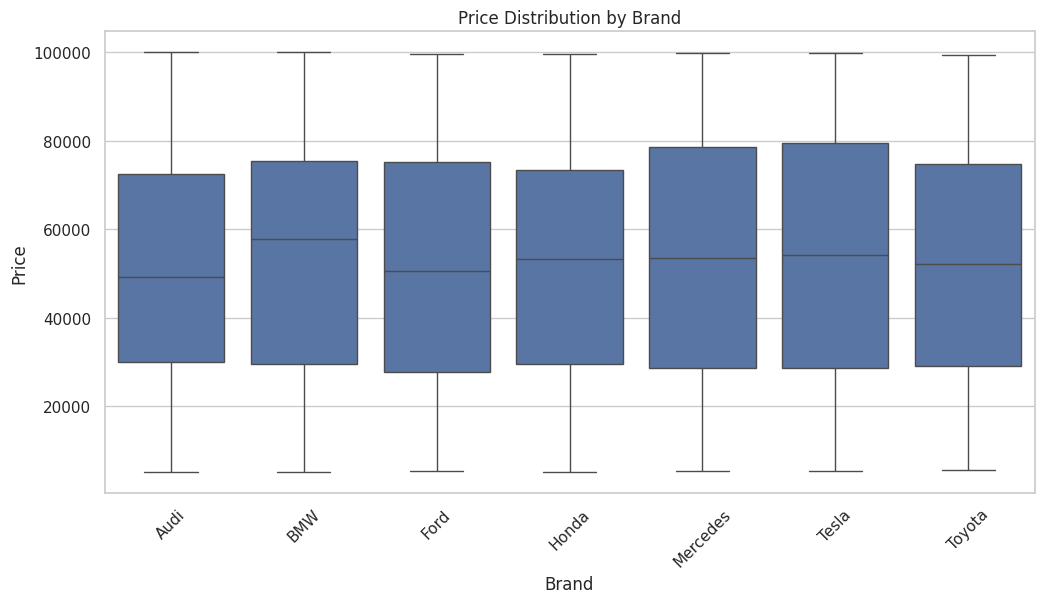

In [48]:
##Price by Brand

plt.figure(figsize=(12,6))
sns.boxplot(x="Brand", y="Price", data=df)
plt.xticks(rotation=45)
plt.title("Price Distribution by Brand")
plt.show()

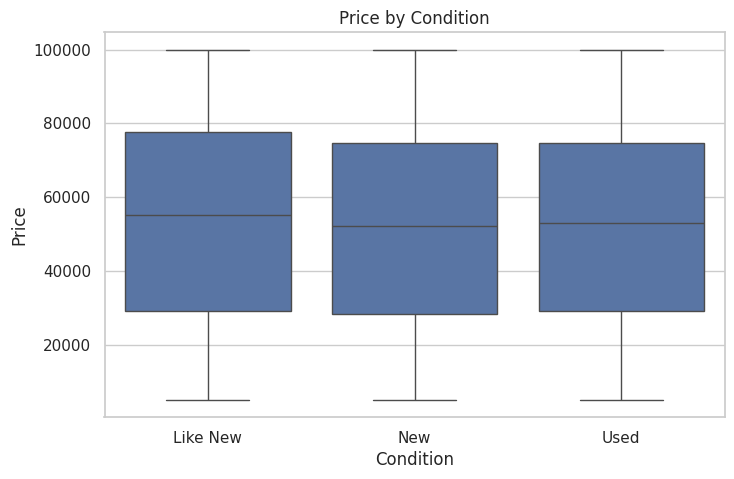

In [50]:
##Price by Condition

plt.figure(figsize=(8,5))
sns.boxplot(x="Condition", y="Price", data=df)
plt.title("Price by Condition")
plt.show()

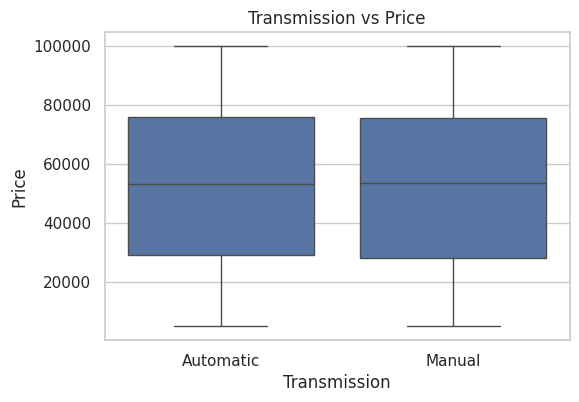

In [51]:
##Transmission vs Price

plt.figure(figsize=(6,4))
sns.boxplot(x="Transmission", y="Price", data=df)
plt.title("Transmission vs Price")
plt.show()

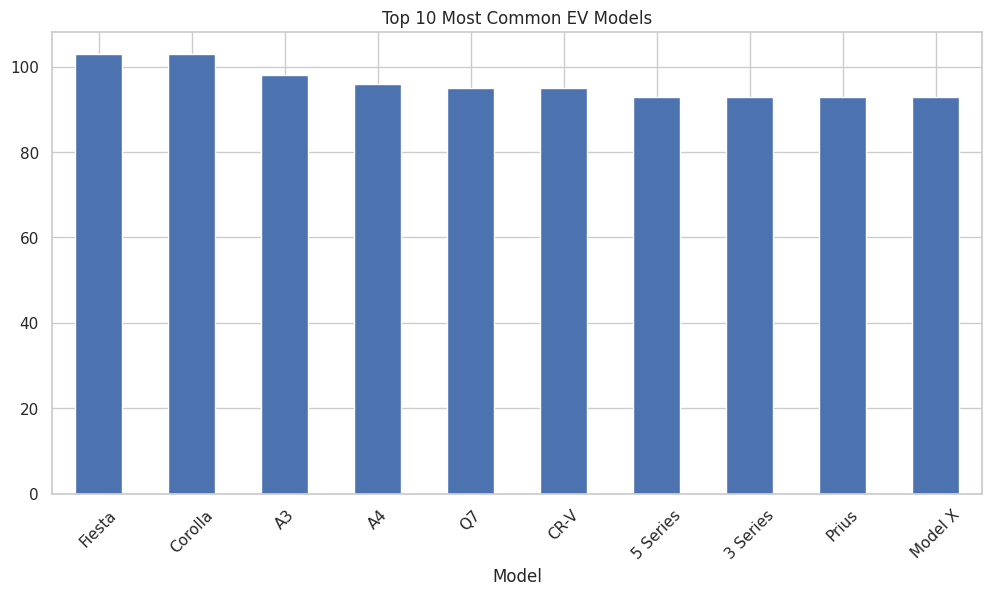

In [52]:
##Top Models

plt.figure(figsize=(12,6))
df["Model"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Most Common EV Models")
plt.xticks(rotation=45)
plt.show()

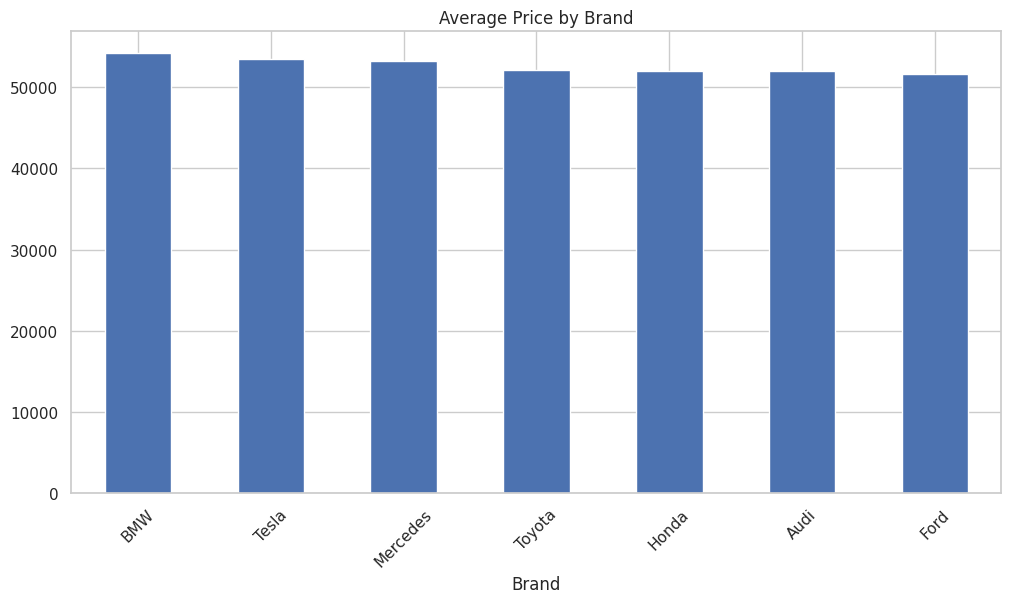

In [53]:
##Average Price by Brand

avg_price_brand = df.groupby("Brand")["Price"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
avg_price_brand.plot(kind="bar")
plt.title("Average Price by Brand")
plt.xticks(rotation=45)
plt.show()

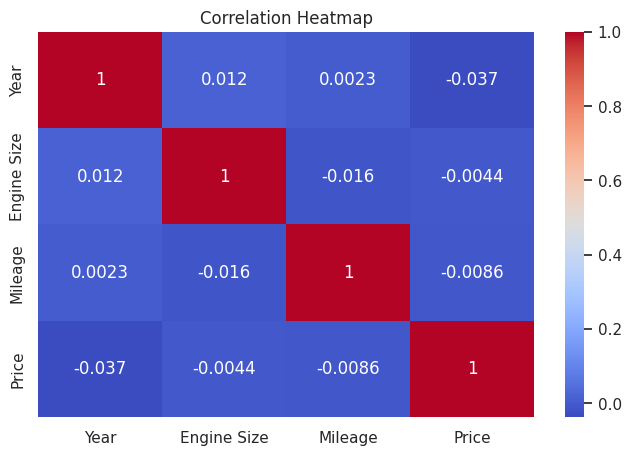

In [54]:
##Correlation Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Data Preparation

In [55]:
##Filter EV Data

# Keep only Electric Vehicles
df = df[df["Fuel Type"].str.lower() == "electric"]

# Reset index (clean)
df = df.reset_index(drop=True)

print(df.shape)
df["Fuel Type"].value_counts()

(614, 9)


,count
Fuel Type,
Electric,614
Diesel,0
Hybrid,0
Petrol,0


In [56]:
##Train/Test split

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(491, 8) (123, 8)


In [57]:
##Preprocessing Pipelines

# Numerical pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine
preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical_features),
    ("cat", cat_pipeline, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(491, 44)
(123, 44)


In [58]:
##Get Feature Names

cat_feature_names = preprocessor.named_transformers_["cat"]["encoder"].get_feature_names_out(categorical_features)

all_feature_names = numerical_features + list(cat_feature_names)

print(len(all_feature_names))

44


In [59]:
##Convert to DataFrame for interpretability

X_train_df = pd.DataFrame(X_train_processed.toarray(), columns=all_feature_names)
X_test_df = pd.DataFrame(X_test_processed.toarray(), columns=all_feature_names)

X_train_df.head()

,Year,Engine Size,Mileage,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Mercedes,Brand_Tesla,Brand_Toyota,...,Model_Model S,Model_Model X,Model_Model Y,Model_Mustang,Model_Prius,Model_Q5,Model_Q7,Model_RAV4,Model_X3,Model_X5
0,0.074571,1.224895,0.156864,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,-1.243545,0.860528,1.607246,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1.536460,1.370642,-1.228088,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.657716,-0.961304,-1.532687,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-1.097088,-1.107051,-1.043923,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [60]:
df["Fuel Type"].unique()

['Electric']
Categories (4, object): ['Diesel', 'Electric', 'Hybrid', 'Petrol']

Modelling

In [61]:
##Linear Regression

lr_model = LinearRegression()

lr_model.fit(X_train_processed, y_train)

y_pred_lr = lr_model.predict(X_test_processed)


mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression Performance:
MAE: 23562.9075808943
RMSE: 27812.98322426826
R2 Score: -0.09857064911401059


In [62]:
##Random Forest

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_processed, y_train)

y_pred_rf = rf_model.predict(X_test_processed)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)


Random Forest Performance:
MAE: 23083.807830081303
RMSE: 26550.94553054857
R2 Score: -0.001135421297956185


In [66]:
##XGBoost

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train_processed, y_train)

y_pred_xgb = xgb_model.predict(X_test_processed)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Performance:")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2 Score:", r2_xgb)

XGBoost Performance:
MAE: 23603.65567898882
RMSE: 27287.78144822699
R2 Score: -0.05747303065787435


In [67]:
##Model Comparison

print("Model Comparison:\n")

print("Linear Regression:")
print(f"MAE: {mae_lr:.2f}, RMSE: {rmse_lr:.2f}, R2: {r2_lr:.2f}\n")

print("Random Forest:")
print(f"MAE: {mae_rf:.2f}, RMSE: {rmse_rf:.2f}, R2: {r2_rf:.2f}\n")


print("XGBoost:")
print(f"MAE: {mae_xgb:.2f}, RMSE: {rmse_xgb:.2f}, R2: {r2_xgb:.2f}")

Model Comparison:

Linear Regression:
MAE: 23562.91, RMSE: 27812.98, R2: -0.10

Random Forest:
MAE: 23083.81, RMSE: 26550.95, R2: -0.00

XGBoost:
MAE: 23603.66, RMSE: 27287.78, R2: -0.06


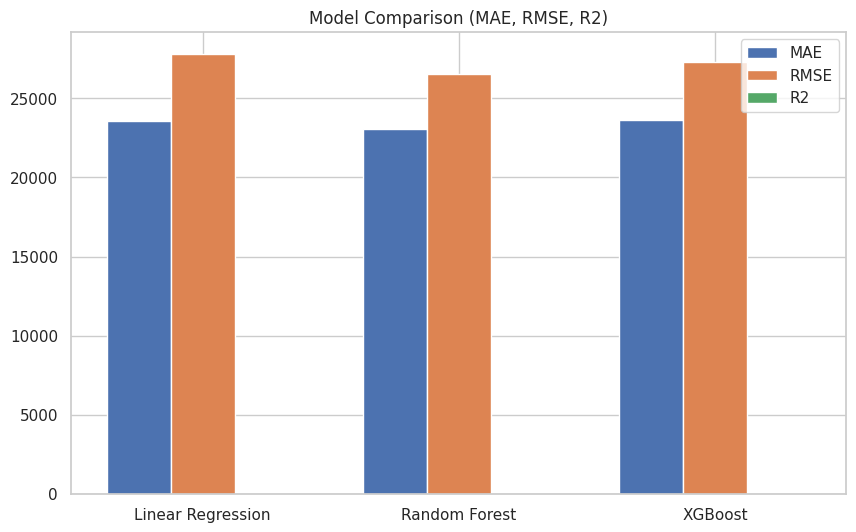

In [68]:
##Model Comparison Plot

import matplotlib.pyplot as plt
import numpy as np

models = ["Linear Regression", "Random Forest", "XGBoost"]

mae_scores = [mae_lr, mae_rf, mae_xgb]
rmse_scores = [rmse_lr, rmse_rf, rmse_xgb]
r2_scores = [r2_lr, r2_rf, r2_xgb]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x - width, mae_scores, width, label="MAE")
plt.bar(x, rmse_scores, width, label="RMSE")
plt.bar(x + width, r2_scores, width, label="R2")

plt.xticks(x, models)
plt.title("Model Comparison (MAE, RMSE, R2)")
plt.legend()

plt.show()

Evaluation

Evaluation Summary:

Linear Regression performs with negative R2, indicating it cannot explain variance in EV prices.
Random Forest performs better of all three with lowest RMSE 26550.95 but R2 ~ 0 suggests not very strong predictive power.
XGBoost does not significantly improve performance over Random Forest with RMSE 27287.78 and R2 -0.06.

Conclusion: None of the models are performing well enough for reliable price prediction.

In [34]:
##Model Performance Interpretation

Evaluation Summary:

Linear Regression performs poorly with negative R2, indicating it cannot explain variance in EV prices.
Random Forest performs slightly better but R2 ~ 0 suggests very weak predictive power.
XGBoost does not significantly improve performance over Random Forest.

Conclusion: None of the models are performing well enough for reliable price prediction.


In [69]:
##Error Analysis

results_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted_RF": y_pred_rf,
    "Predicted_XGB": y_pred_xgb
})

results_df["Error_RF"] = results_df["Actual"] - results_df["Predicted_RF"]
results_df["Error_XGB"] = results_df["Actual"] - results_df["Predicted_XGB"]

results_df.head()

,Actual,Predicted_RF,Predicted_XGB,Error_RF,Error_XGB
350,59159.81,46535.8805,41906.238281,12623.9295,17253.571719
377,78235.35,50067.5498,65966.320312,28167.8002,12269.029688
163,81157.49,37897.2258,45428.031250,43260.2642,35729.458750
609,57367.93,49682.9650,48118.828125,7684.9650,9249.101875
132,56874.38,51854.7960,52329.214844,5019.5840,4545.165156


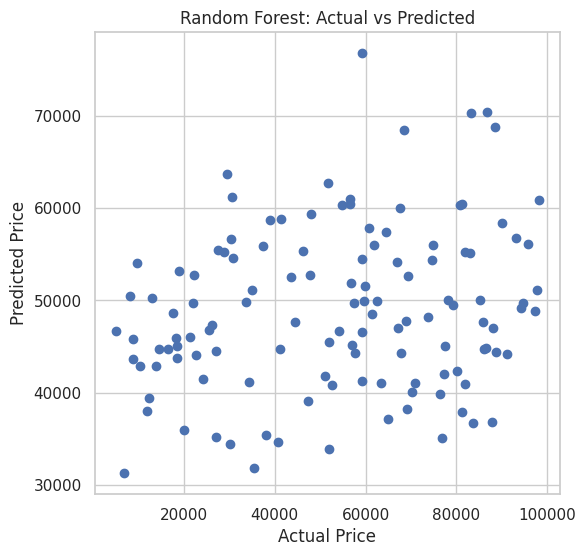

In [70]:
##Plot Predictions Vs Actual

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

In [37]:
##Key Insight

Key Insights:

1. Models show very low predictive power (R2 near 0 or negative).
2. High MAE (~$23k) indicates large prediction errors.
3. Dataset likely lacks important EV-specific features such as battery range, battery health, or charging history.
4. Filtering reduced dataset size to 614, limiting model learning.
5. Current features (Engine Size, Mileage, etc.) are not strong predictors for EV pricing.


In [38]:
##Business Evaluation

Business Evaluation:

The current model is not reliable for real-world EV price prediction.
Prediction errors are too large to support pricing decisions.
However, the analysis highlights key data gaps and areas for improvement.


In [39]:
##Final Conclusion

Final Conclusion:

This project demonstrates that predicting EV resale prices requires more specialized features.
While the models built provide a baseline, their performance is insufficient for deployment.
Future improvements should focus on better data collection and feature engineering.
